
# Stacking Ensemble Regressors 

Objective: Develop and optimise stacking ensemble models with multiple meta-learners
(Elastic Net, Ridge, XGBoost, LightGBM, Random Forest) using Optuna Bayesian HPO.
Evaluate with a full suite of performance indices and produce publication-ready figures
including spider plot, REC curve, Taylor diagram, and SHAP analysis.


In [1]:

# ── 1. IMPORTS
import warnings, time, pickle, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import NuSVR
from sklearn.neighbors import NearestNeighbors
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_is_fitted, check_array
from scipy.spatial.distance import cdist
from numpy.linalg import pinv
from sklearn.metrics import (
    explained_variance_score, max_error, mean_absolute_error,
    mean_squared_error, median_absolute_error,
    mean_absolute_percentage_error, r2_score,
    mean_tweedie_deviance, mean_pinball_loss
)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Publication-quality style
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 9,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})

PALETTE = {
    'primary'  : '#1f4e79',
    'secondary': '#c55a11',
    'pos'      : '#2e75b6',
    'neg'      : '#c00000',
}

print("Imports OK")
print(f"XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | SHAP {shap.__version__}")


Imports OK
XGBoost 3.0.0 | LightGBM 4.6.0 | SHAP 0.47.2



## 2. Data Loading and Pre-processing

Reproduces the established pipeline: feature engineering, asymmetric IQR outlier
removal (training set only), Yeo-Johnson power transform, and z-score standardisation.


In [2]:

# ── 2.1  Load & clean
df = pd.read_excel('data-p.xlsx')
processed_data = df.copy()
processed_data.columns = [col.strip() for col in processed_data.columns]

# ── 2.2  Engineered features
if all(c in processed_data.columns for c in ['dimensions', 'span length of specimen']):
    processed_data['aspect_ratio'] = (
        processed_data['span length of specimen'] / processed_data['dimensions'])

if all(c in processed_data.columns for c in ['axial load ratio', 'confinement']):
    processed_data['load_confinement_interaction'] = (
        processed_data['axial load ratio'] / processed_data['confinement'])

if all(c in processed_data.columns for c in ['axial load ratio', 'scaled stand off distance']):
    processed_data['loading_interaction'] = (
        processed_data['scaled stand off distance'] * processed_data['axial load ratio'])

# ── 2.3  Drop raw columns
TARGET_COL = 'peak deformation (mm)'
DROP_COLS  = ['dimensions', 'span length of specimen',
              'grade of concrete(Mpa)', 'yield strength of the steel (Mpa)']
processed_data = processed_data.drop(columns=DROP_COLS)

X = processed_data.drop(columns=[TARGET_COL])
y = processed_data[TARGET_COL]

# ── 2.4  Formal feature labels (used in all plots)
FEATURE_LABELS = {
    'scaled stand off distance'   : r'Scaled Standoff Distance $Z$ ($\mathrm{m/kg}^{1/3}$)',
    'axial load ratio'            : r'Axial Load Ratio $n$ (-)',
    'confinement'                 : r'Confinement Factor $\xi$ (-)',
    'loading_interaction'         : r'Loading Interaction (-)',
    'aspect_ratio'                : r'Aspect Ratio (-)',
    'load_confinement_interaction': r'Load-Confinement Interaction (-)',
    'peak deformation (mm)'       : r'Peak Deformation $\delta$ (mm)',
    'Rx2'                         : r'End-support Conditions (-)',
    'shape of the cross section'  : r'Cross-section Shape (-)',
}
FEATURE_NAMES = list(X.columns)

# ── 2.5  Encode categorical
le = LabelEncoder()
X['shape of the cross section'] = le.fit_transform(X['shape of the cross section'])

# ── 2.6  Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

# ── 2.7  Outlier removal (IQR, training set only)
Q1, Q3  = y_train.quantile(0.25), y_train.quantile(0.75)
IQR     = Q3 - Q1
lb, ub  = Q1 - 4.0 * IQR, Q3 + 1.5 * IQR
mask    = (y_train >= lb) & (y_train <= ub)
X_train = X_train[mask].reset_index(drop=True)
y_train = y_train[mask].reset_index(drop=True)

# ── 2.8  Yeo-Johnson
SKEWED = ['scaled stand off distance', 'confinement']
pt = PowerTransformer(method='yeo-johnson')
X_train[SKEWED] = pt.fit_transform(X_train[SKEWED])
X_test[SKEWED]  = pt.transform(X_test[SKEWED])

# ── 2.9  Standardise
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

feat_labels_list = [FEATURE_LABELS.get(fn, fn) for fn in FEATURE_NAMES]

print(f"Train: {X_train_s.shape[0]} samples | Test: {X_test_s.shape[0]} samples | Features: {X_train_s.shape[1]}")
print(f"Target range (train): [{y_train.min():.2f}, {y_train.max():.2f}] mm")


Train: 111 samples | Test: 30 samples | Features: 8
Target range (train): [0.00, 49.10] mm



## 3. Custom LocallyWeightedKNNRegressor and Model Loading

The pre-trained KNN model (`knn.pkl`) uses a custom `LocallyWeightedKNNRegressor`.
We re-define the class here (inheriting from `BaseEstimator`, `RegressorMixin`) so it:
- Unpickles correctly in this environment
- Is fully compatible with `StackingRegressor`, `cross_val_score`, and SHAP


In [3]:

class LocallyWeightedKNNRegressor(RegressorMixin, BaseEstimator):
    """
    Fits a local linear model within the K-neighbourhood of each query
    point using Tricube (default) kernel weights.

    Uses cdist for vectorised distance computation; falls back to
    a kernel-weighted mean when the neighbourhood is too small for
    stable linear regression.
    """
    _estimator_type = "regressor"   # required for sklearn StackingRegressor

    def __init__(self, n_neighbors: int = 20, local_model: str = 'linear',
                 kernel: str = 'tricube', reg_alpha: float = 1e-3):
        self.n_neighbors = n_neighbors
        self.local_model = local_model
        self.kernel      = kernel
        self.reg_alpha   = reg_alpha

    def _kernel_weights(self, u):
        if self.kernel == 'tricube':
            return np.where(u < 1, (1 - np.abs(u)**3)**3, 0.0)
        if self.kernel == 'gaussian':
            return np.exp(-0.5 * (u * 3)**2)   # sigma = h/3
        if self.kernel == 'epanechnikov':
            return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)
        raise ValueError(f'Unknown kernel: {self.kernel}')

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        D     = cdist(X, self.X_train_, metric='euclidean')
        preds = np.empty(len(X))
        for i, (d, x_q) in enumerate(zip(D, X)):
            idx = np.argsort(d)[:self.n_neighbors]
            d_k = d[idx]; y_k = self.y_train_[idx]; X_k = self.X_train_[idx]
            h   = d_k.max() + 1e-12
            w   = self._kernel_weights(d_k / h)
            if self.local_model == 'constant' or X_k.shape[0] <= X_k.shape[1] + 1:
                preds[i] = np.dot(w, y_k) / (w.sum() + 1e-10)
            else:
                W    = np.diag(w)
                A    = np.column_stack([np.ones(len(X_k)), X_k])
                AtW  = A.T @ W
                AtWA = AtW @ A + self.reg_alpha * np.eye(A.shape[1])
                AtWy = AtW @ y_k
                try:
                    beta = np.linalg.solve(AtWA, AtWy)
                except np.linalg.LinAlgError:
                    beta = pinv(AtWA) @ AtWy
                preds[i] = np.r_[1.0, x_q] @ beta
        return preds
        
# Load pre-trained models
with open('saved_models/knn.pkl',               'rb') as f: knn_loaded = pickle.load(f)
with open('saved_models/LR_best_model.pkl',     'rb') as f: lr_loaded  = pickle.load(f)
with open('saved_models/NuSVR_rbf_optimised.pkl','rb') as f: svr_loaded = pickle.load(f)

knn_loaded._estimator_type = "regressor"

print("Models loaded:")
print(f"  KNN   n_neighbors={knn_loaded.n_neighbors}, kernel={knn_loaded.kernel}, local_model={knn_loaded.local_model}")
print(f"  LR    type={type(lr_loaded).__name__}, steps={[s[0] for s in lr_loaded.steps]}")
print(f"  NuSVR C={svr_loaded.C:.4f}, nu={svr_loaded.nu:.4f}, kernel={svr_loaded.kernel}")

def _make_fresh_knn():
    """
    Build a fresh LocallyWeightedKNNRegressor from the CURRENT class definition
    (which has _estimator_type = "regressor" at class level), copying the
    hyperparameters and fitted data from the loaded pickle.

    This is necessary because sklearn.clone() re-instantiates estimators via
    __init__() + get_params().  The loaded pickle's __class__ still resolves
    to the OLD __main__.LocallyWeightedKNNRegressor that was serialised without
    _estimator_type, so any instance-level stamp is lost after cloning.
    Building from the current class avoids that entirely.
    """
    fresh = LocallyWeightedKNNRegressor(
        n_neighbors  = knn_loaded.n_neighbors,
        local_model  = knn_loaded.local_model,
        kernel       = knn_loaded.kernel,
        reg_alpha    = knn_loaded.reg_alpha,
    )
    # Transfer fitted state so the object is ready to predict immediately
    fresh.X_train_ = knn_loaded.X_train_.copy()
    fresh.y_train_ = knn_loaded.y_train_.copy()
    return fresh

def get_base_estimators():
    """
    Return a fresh list of (name, estimator) tuples for StackingRegressor.

    knn is rebuilt from the current class on every call so that sklearn's
    clone() always gets an object whose __class__ carries _estimator_type.
    lr and nusvr are native sklearn objects and clone cleanly as-is.
    """
    return [
        ('knn',   _make_fresh_knn()),
        ('nusvr', svr_loaded),
        ('lr',    lr_loaded),
    ]


Models loaded:
  KNN   n_neighbors=5, kernel=tricube, local_model=linear
  LR    type=Pipeline, steps=['poly', 'scaler', 'regressor']
  NuSVR C=196.0908, nu=0.5849, kernel=rbf



## 4. Bayesian Hyperparameter Optimisation with Optuna

Five meta-learner candidates are optimised via the TPE sampler with 5-fold cross-validation.
Objective: minimise Mean Absolute Error (MAE) on the training set.

| Meta-learner | Search space |
|---|---|
| Elastic Net | alpha, l1_ratio |
| Ridge | alpha |
| XGBoost | n_estimators, max_depth, lr, subsample, colsample_bytree, reg_alpha, reg_lambda |
| LightGBM | n_estimators, num_leaves, lr, subsample, colsample_bytree, reg_alpha, reg_lambda |
| Random Forest | n_estimators, max_depth, min_samples_split, min_samples_leaf |


In [4]:

META_CONFIGS = {
    'elastic_net'  : {'label': 'Stacking + Elastic Net',  'color': '#1f4e79'},
    'ridge'        : {'label': 'Stacking + Ridge',         'color': '#2e75b6'},
    'xgboost'      : {'label': 'Stacking + XGBoost',       'color': '#c55a11'},
    'lightgbm'     : {'label': 'Stacking + LightGBM',      'color': '#375623'},
    'random_forest': {'label': 'Stacking + Random Forest', 'color': '#7030a0'},
}

def make_objective(meta_name, X_tr, y_tr):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        if meta_name == 'elastic_net':
            meta = ElasticNet(
                alpha    = trial.suggest_float('alpha',    1e-4, 10.0, log=True),
                l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99),
                max_iter=5000, random_state=RANDOM_STATE)
        elif meta_name == 'ridge':
            meta = Ridge(alpha=trial.suggest_float('alpha', 1e-3, 200.0, log=True))
        elif meta_name == 'xgboost':
            meta = xgb.XGBRegressor(
                n_estimators     = trial.suggest_int  ('n_estimators',    50, 500),
                max_depth        = trial.suggest_int  ('max_depth',         2,   8),
                learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample',       0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha',      1e-4,10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda',     1e-4,10.0, log=True),
                random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
        elif meta_name == 'lightgbm':
            meta = lgb.LGBMRegressor(
                n_estimators     = trial.suggest_int  ('n_estimators',    50, 500),
                num_leaves       = trial.suggest_int  ('num_leaves',       10, 127),
                learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.3, log=True),
                subsample        = trial.suggest_float('subsample',       0.5, 1.0),
                colsample_bytree = trial.suggest_float('colsample_bytree',0.5, 1.0),
                reg_alpha        = trial.suggest_float('reg_alpha',      1e-4,10.0, log=True),
                reg_lambda       = trial.suggest_float('reg_lambda',     1e-4,10.0, log=True),
                random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
        elif meta_name == 'random_forest':
            meta = RandomForestRegressor(
                n_estimators      = trial.suggest_int('n_estimators',     50, 400),
                max_depth         = trial.suggest_int('max_depth',          2,  20),
                min_samples_split = trial.suggest_int('min_samples_split',  2,  20),
                min_samples_leaf  = trial.suggest_int('min_samples_leaf',   1,  10),
                random_state=RANDOM_STATE, n_jobs=-1)

        stk = StackingRegressor(
            estimators=get_base_estimators(), final_estimator=meta,
            cv=5, passthrough=False, n_jobs=-1)
        scores = cross_val_score(stk, X_tr, y_tr,
                                 cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
        return -scores.mean()

    return objective

N_TRIALS = 60   # Increase to 150+ for final publication run

best_params  = {}
study_values = {}

print(f"Running Optuna HPO ({N_TRIALS} trials x 5-fold CV per meta-learner)\n")
for name in META_CONFIGS:
    t0    = time.time()
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(make_objective(name, X_train_s, y_train),
                   n_trials=N_TRIALS, show_progress_bar=False)
    elapsed = time.time() - t0
    best_params[name]  = study.best_params
    study_values[name] = [t.value for t in study.trials]
    print(f"  [{name:14s}]  best CV-MAE = {study.best_value:.4f} mm  ({elapsed:.1f}s)")
    print(f"              best params: {study.best_params}\n")


Running Optuna HPO (60 trials x 5-fold CV per meta-learner)

  [elastic_net   ]  best CV-MAE = 1.4556 mm  (18.4s)
              best params: {'alpha': 4.122108904992045, 'l1_ratio': 0.012894031277086616}

  [ridge         ]  best CV-MAE = 1.4623 mm  (10.6s)
              best params: {'alpha': 198.55632735362946}

  [xgboost       ]  best CV-MAE = 1.6250 mm  (14.2s)
              best params: {'n_estimators': 223, 'max_depth': 3, 'learning_rate': 0.04176042175566856, 'subsample': 0.6430250773812685, 'colsample_bytree': 0.955892631943178, 'reg_alpha': 0.00025379394687242773, 'reg_lambda': 6.00497861425125}

  [lightgbm      ]  best CV-MAE = 3.6216 mm  (29.4s)
              best params: {'n_estimators': 366, 'num_leaves': 109, 'learning_rate': 0.023232580204941105, 'subsample': 0.6977470993128554, 'colsample_bytree': 0.8340118830896328, 'reg_alpha': 0.0011191132131412168, 'reg_lambda': 0.06482910234170237}

  [random_forest ]  best CV-MAE = 1.6304 mm  (31.9s)
              best params: {

## 5. Train Final Stacking Models

In [5]:

def build_meta(name, params):
    p = params.copy()
    if name == 'elastic_net':
        return ElasticNet(**p, max_iter=5000, random_state=RANDOM_STATE)
    elif name == 'ridge':
        return Ridge(**p)
    elif name == 'xgboost':
        return xgb.XGBRegressor(**p, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    elif name == 'lightgbm':
        return lgb.LGBMRegressor(**p, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    elif name == 'random_forest':
        return RandomForestRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1)

fitted_models = {}
train_times   = {}

for name in META_CONFIGS:
    meta = build_meta(name, best_params[name])
    stk  = StackingRegressor(
        estimators=get_base_estimators(), final_estimator=meta,
        cv=5, passthrough=False, n_jobs=-1)
    t0 = time.time()
    stk.fit(X_train_s, y_train)
    train_times[name]   = time.time() - t0
    fitted_models[name] = stk
    print(f"  [{name:14s}]  trained in {train_times[name]:.2f}s")

print("\nAll stacking models fitted.")


  [elastic_net   ]  trained in 0.09s
  [ridge         ]  trained in 0.10s
  [xgboost       ]  trained in 0.27s
  [lightgbm      ]  trained in 0.17s
  [random_forest ]  trained in 0.36s

All stacking models fitted.



## 6. Comprehensive Performance Evaluation

Metrics computed on training and hold-out test sets, plus 10-fold CV R².

**A10-index**: fraction of predictions within 10% of the observed value.
**MSLE**: mean squared logarithmic error.
**Pinball loss**: at quantile tau=0.5 (equals MAE/2).
**Tweedie deviance**: power=1.5.


In [6]:

def a10_index(y_true, y_pred):
    ratio = np.abs(y_pred - y_true) / (np.abs(y_true) + 1e-10)
    return float(np.mean(ratio <= 0.10))

def msle_safe(y_true, y_pred):
    return float(np.mean((np.log1p(np.clip(y_true,0,None)) -
                          np.log1p(np.clip(y_pred,0,None)))**2))

def compute_metrics(y_true, y_pred, label=''):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rmse   = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        'Set'              : label,
        'R2'               : float(r2_score(y_true, y_pred)),
        'Explained Var.'   : float(explained_variance_score(y_true, y_pred)),
        'MAE (mm)'         : float(mean_absolute_error(y_true, y_pred)),
        'RMSE (mm)'        : rmse,
        'Max Error (mm)'   : float(max_error(y_true, y_pred)),
        'MedAE (mm)'       : float(median_absolute_error(y_true, y_pred)),
        'MAPE (%)'         : float(mean_absolute_percentage_error(y_true, y_pred)*100),
        'MSLE'             : msle_safe(y_true, y_pred),
        'Pinball (t=0.5)'  : float(mean_pinball_loss(y_true, y_pred, alpha=0.5)),
        'Tweedie (p=1.5)'  : float(mean_tweedie_deviance(y_true, y_pred, power=1.5)),
        'A10-index'        : a10_index(y_true, y_pred),
    }

predictions = {}
records     = []

print("Computing metrics ...\n")
for name, cfg in META_CONFIGS.items():
    model = fitted_models[name]
    ytr_p = model.predict(X_train_s)
    yte_p = model.predict(X_test_s)
    predictions[name] = {'train': ytr_p, 'test': yte_p}

    # CV R2
    meta   = build_meta(name, best_params[name])
    stk_cv = StackingRegressor(
        estimators=get_base_estimators(), final_estimator=meta,
        cv=5, passthrough=False, n_jobs=-1)
    cv_sc  = cross_val_score(stk_cv, X_train_s, y_train,
                              cv=KFold(10, shuffle=True, random_state=RANDOM_STATE),
                              scoring='r2', n_jobs=-1)
    cv_mu, cv_sd = cv_sc.mean(), cv_sc.std()

    for split, yp in [('Train', ytr_p), ('Test', yte_p)]:
        yt = y_train if split == 'Train' else y_test
        row = compute_metrics(yt, yp, split)
        row['Model']          = cfg['label']
        row['Train Time (s)'] = round(train_times[name], 3)
        row['CV R2 (mean)']   = round(float(cv_mu), 4)
        row['CV R2 (std)']    = round(float(cv_sd), 4)
        records.append(row)

    tr, te = records[-2], records[-1]
    print(f"  {cfg['label']}")
    print(f"    Train  R2={tr['R2']:.4f}  MAE={tr['MAE (mm)']:.4f}  RMSE={tr['RMSE (mm)']:.4f}  A10={tr['A10-index']:.3f}")
    print(f"    Test   R2={te['R2']:.4f}  MAE={te['MAE (mm)']:.4f}  RMSE={te['RMSE (mm)']:.4f}  A10={te['A10-index']:.3f}")
    print(f"    CV-R2  {cv_mu:.4f} +/- {cv_sd:.4f}\n")

metrics_df = pd.DataFrame(records)
col_order  = ['Model','Set','Train Time (s)','CV R2 (mean)','CV R2 (std)',
               'R2','Explained Var.','MAE (mm)','RMSE (mm)','Max Error (mm)',
               'MedAE (mm)','MAPE (%)','MSLE','Pinball (t=0.5)',
               'Tweedie (p=1.5)','A10-index']
metrics_df = metrics_df[col_order]

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 220)
print(metrics_df[metrics_df['Set']=='Test'].to_string(index=False))


Computing metrics ...

  Stacking + Elastic Net
    Train  R2=0.9832  MAE=0.8284  RMSE=1.6820  A10=0.865
    Test   R2=0.9616  MAE=1.2310  RMSE=2.5712  A10=0.833
    CV-R2  0.9350 +/- 0.0826

  Stacking + Ridge
    Train  R2=0.9851  MAE=0.8403  RMSE=1.5832  A10=0.865
    Test   R2=0.9646  MAE=1.2479  RMSE=2.4676  A10=0.833
    CV-R2  0.9334 +/- 0.0831

  Stacking + XGBoost
    Train  R2=0.9598  MAE=1.3822  RMSE=2.5995  A10=0.793
    Test   R2=0.9370  MAE=1.8882  RMSE=3.2918  A10=0.700
    CV-R2  0.9188 +/- 0.1097

  Stacking + LightGBM
    Train  R2=0.9391  MAE=1.8236  RMSE=3.1990  A10=0.802
    Test   R2=0.9349  MAE=1.9095  RMSE=3.3471  A10=0.767
    CV-R2  0.7530 +/- 0.2432

  Stacking + Random Forest
    Train  R2=0.9777  MAE=0.9948  RMSE=1.9333  A10=0.838
    Test   R2=0.9402  MAE=1.6149  RMSE=3.2074  A10=0.767
    CV-R2  0.9259 +/- 0.0918

                   Model  Set  Train Time (s)  CV R2 (mean)  CV R2 (std)     R2  Explained Var.  MAE (mm)  RMSE (mm)  Max Error (mm)  MedAE (mm

## 7. Publication-Ready Visualisations

### 7.1 Predicted vs. Observed

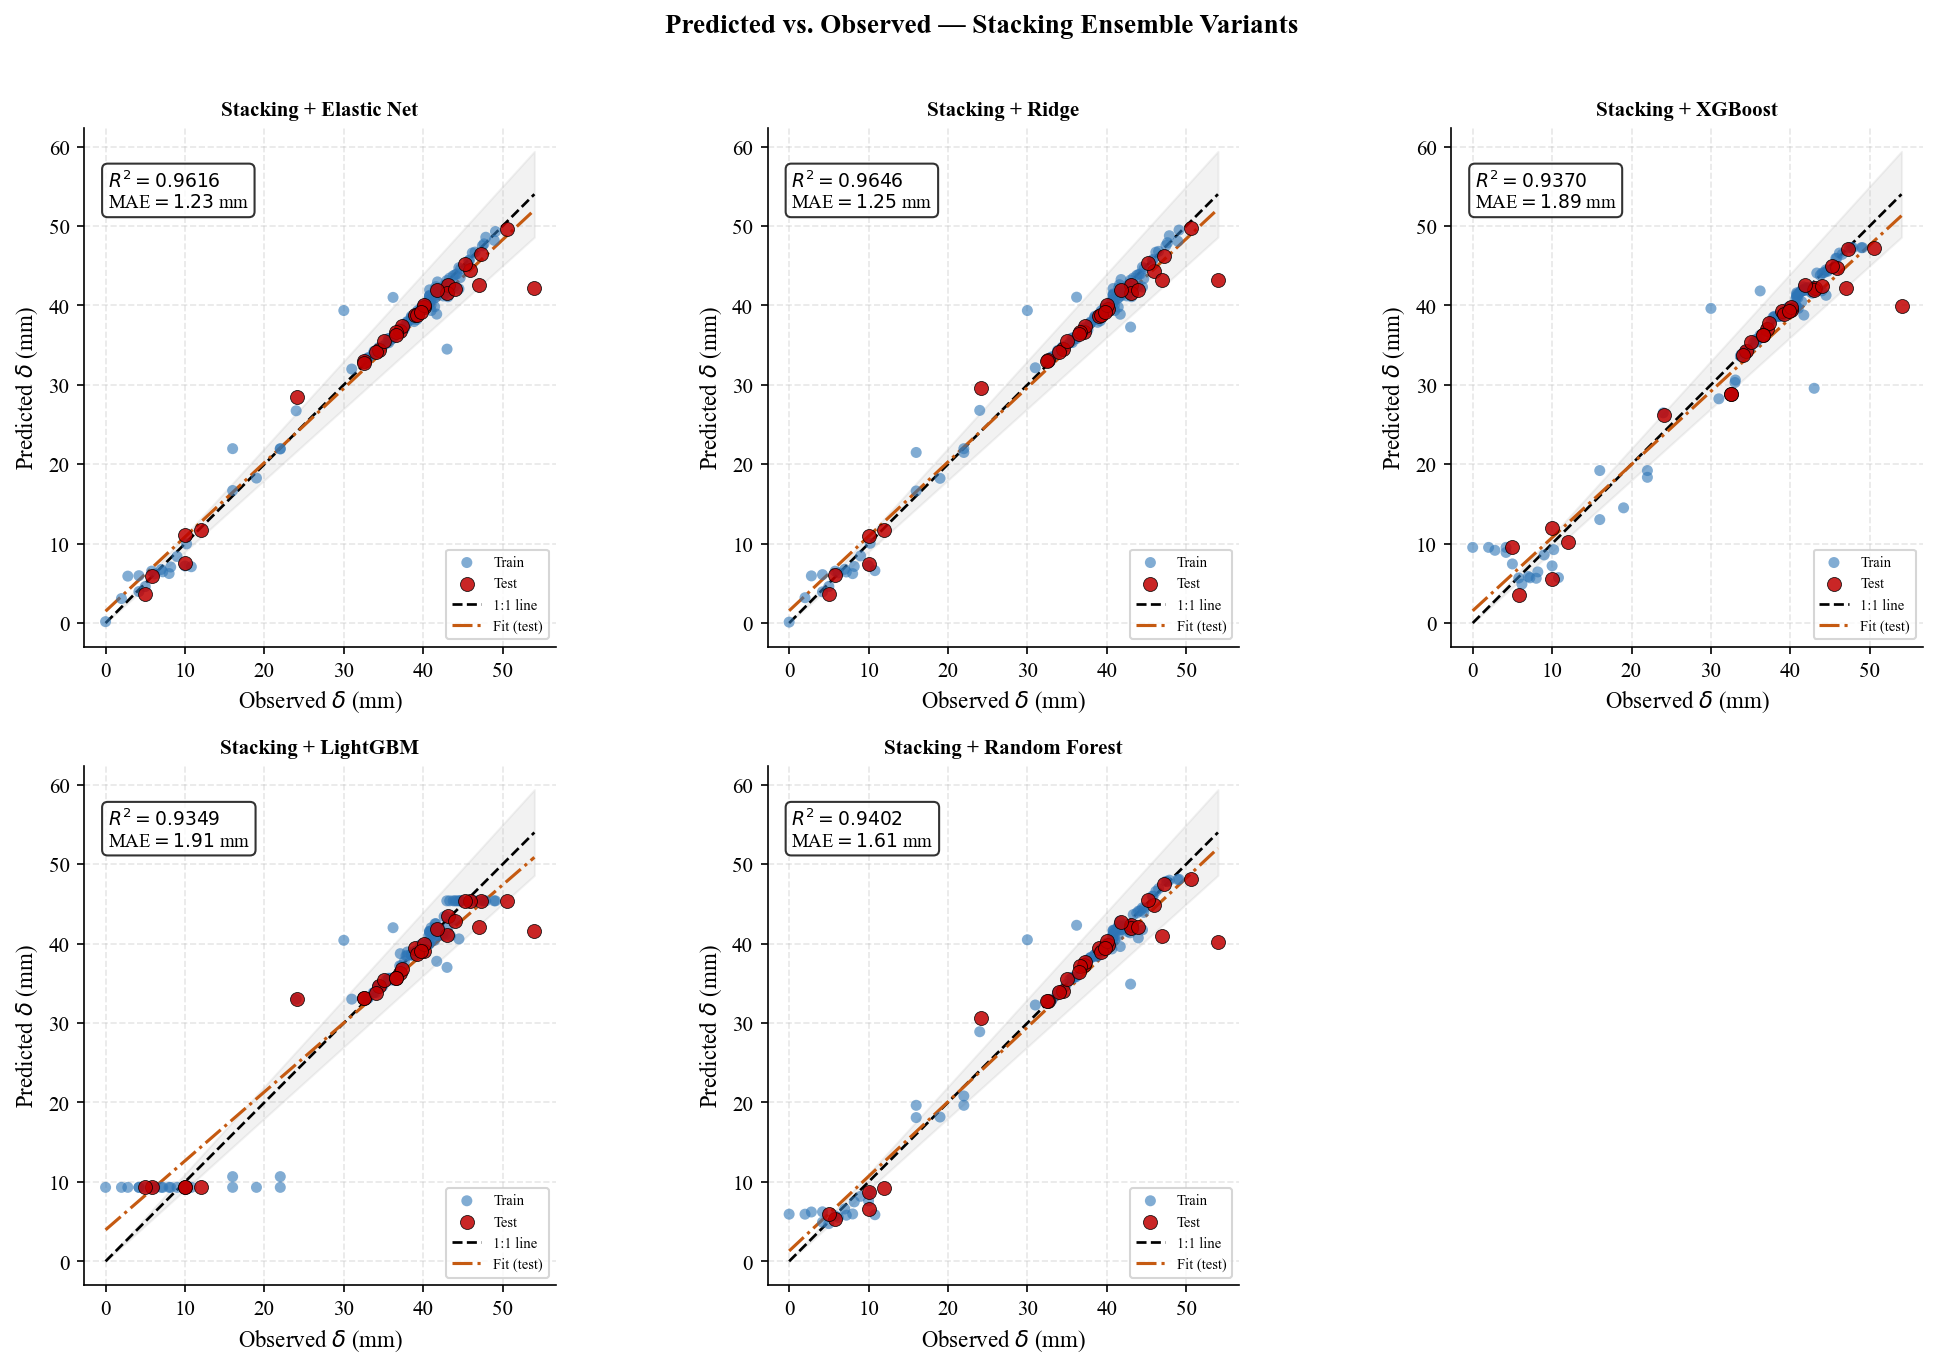

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for ax_idx, (name, cfg) in enumerate(META_CONFIGS.items()):
    ax    = axes[ax_idx]
    ytr_p = predictions[name]['train']
    yte_p = predictions[name]['test']

    mn = float(min(y_train.min(), y_test.min()))
    mx = float(max(y_train.max(), y_test.max()))

    ax.scatter(y_train, ytr_p, s=28, alpha=0.6, color='#2e75b6',
               edgecolors='none', label='Train', zorder=3)
    ax.scatter(y_test,  yte_p, s=45, alpha=0.85, color='#c00000',
               edgecolors='k', linewidths=0.4, label='Test', zorder=5)
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.3, label='1:1 line')

    # regression line (test)
    m_, b_, *_ = stats.linregress(y_test, yte_p)
    xs = np.linspace(mn, mx, 200)
    ax.plot(xs, m_*xs + b_, color='#c55a11', lw=1.5, ls='-.', label='Fit (test)')

    # ±10% band
    ax.fill_between([mn, mx], [0.9*mn, 0.9*mx], [1.1*mn, 1.1*mx],
                    alpha=0.10, color='grey')

    r2_te  = r2_score(y_test, yte_p)
    mae_te = mean_absolute_error(y_test, yte_p)
    ax.text(0.05, 0.92,
            f'$R^2={r2_te:.4f}$\nMAE$={mae_te:.2f}$ mm',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    ax.set_title(cfg['label'], fontsize=10, fontweight='bold')
    ax.set_xlabel(r'Observed $\delta$ (mm)')
    ax.set_ylabel(r'Predicted $\delta$ (mm)')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal', adjustable='box')

for ax in axes[len(META_CONFIGS):]:
    ax.set_visible(False)

fig.suptitle('Predicted vs. Observed — Stacking Ensemble Variants',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_pred_obs.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.2 Residual Analysis

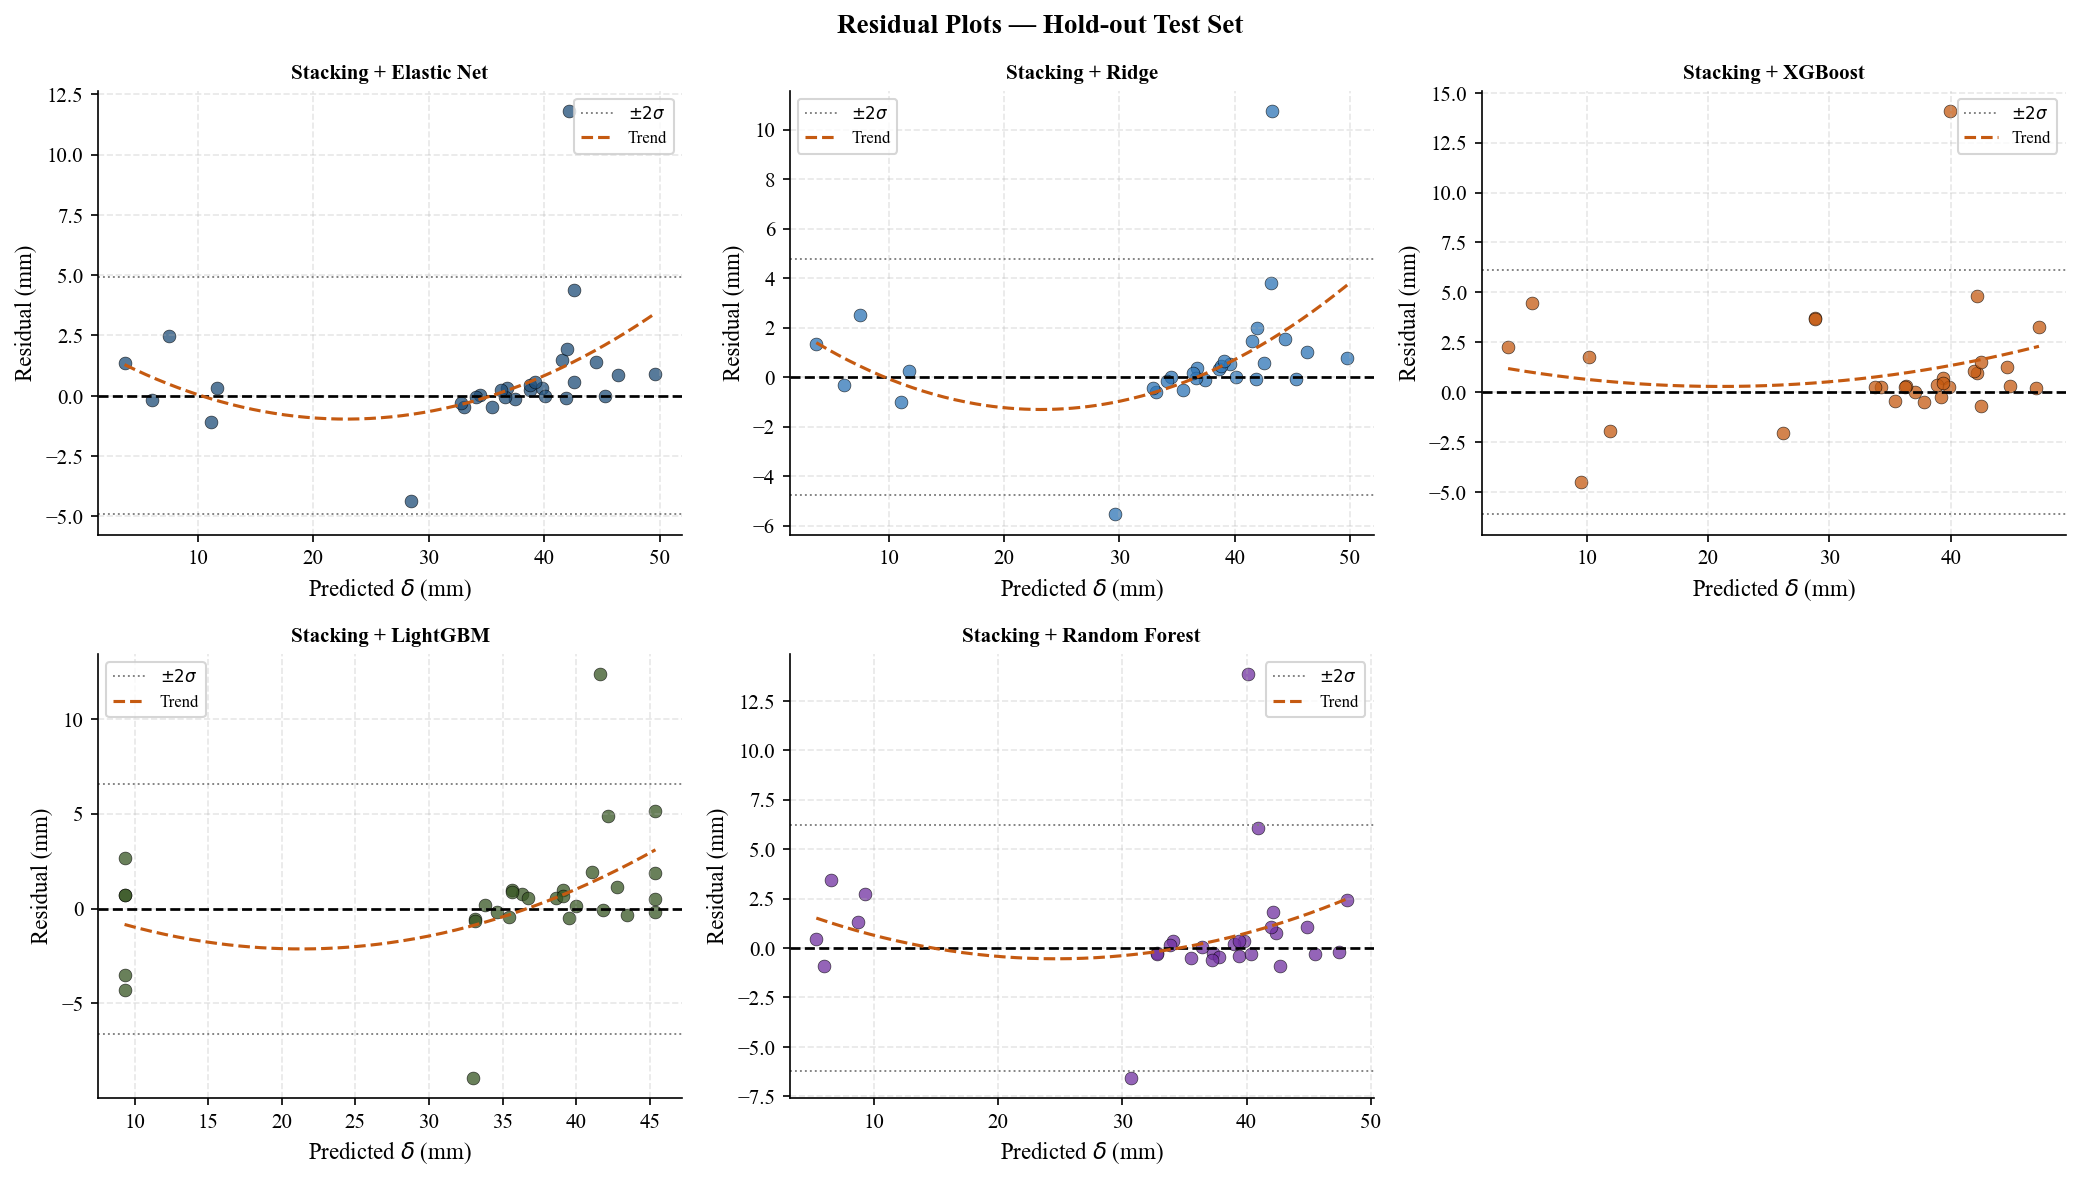

In [8]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax_idx, (name, cfg) in enumerate(META_CONFIGS.items()):
    ax     = axes[ax_idx]
    yte_p  = predictions[name]['test']
    resids = y_test.values - yte_p

    ax.scatter(yte_p, resids, s=38, alpha=0.75,
               color=cfg['color'], edgecolors='k', linewidths=0.3)
    ax.axhline(0,               color='k',    lw=1.3, ls='--')
    ax.axhline( 2*resids.std(), color='grey', lw=0.9, ls=':', label=r'$\pm 2\sigma$')
    ax.axhline(-2*resids.std(), color='grey', lw=0.9, ls=':')

    p  = np.polyfit(yte_p, resids, deg=2)
    xs = np.linspace(yte_p.min(), yte_p.max(), 200)
    ax.plot(xs, np.polyval(p, xs), color='#c55a11', lw=1.5, ls='--', label='Trend')

    ax.set_title(cfg['label'], fontsize=10, fontweight='bold')
    ax.set_xlabel(r'Predicted $\delta$ (mm)')
    ax.set_ylabel('Residual (mm)')
    ax.legend(fontsize=8)

for ax in axes[len(META_CONFIGS):]:
    ax.set_visible(False)

fig.suptitle('Residual Plots — Hold-out Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_residuals.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.3 Error Distribution (KDE)

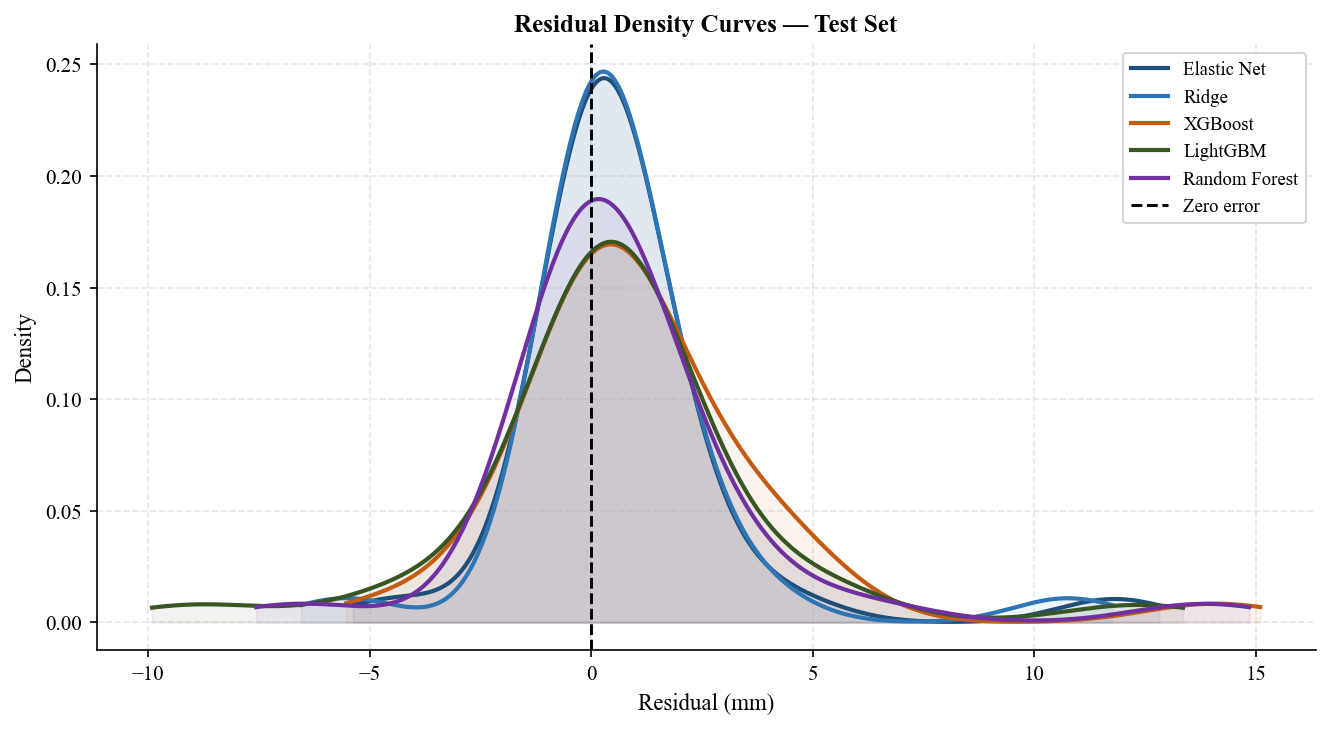

In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
for name, cfg in META_CONFIGS.items():
    resids = y_test.values - predictions[name]['test']
    kde    = stats.gaussian_kde(resids, bw_method='scott')
    xs     = np.linspace(resids.min()-1, resids.max()+1, 400)
    ax.plot(xs, kde(xs), lw=2, color=cfg['color'],
            label=cfg['label'].replace('Stacking + ',''))
    ax.fill_between(xs, kde(xs), alpha=0.07, color=cfg['color'])

ax.axvline(0, color='k', lw=1.4, ls='--', label='Zero error')
ax.set_xlabel('Residual (mm)')
ax.set_ylabel('Density')
ax.set_title('Residual Density Curves — Test Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_error_dist.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.4 Metric Bar Chart Comparison

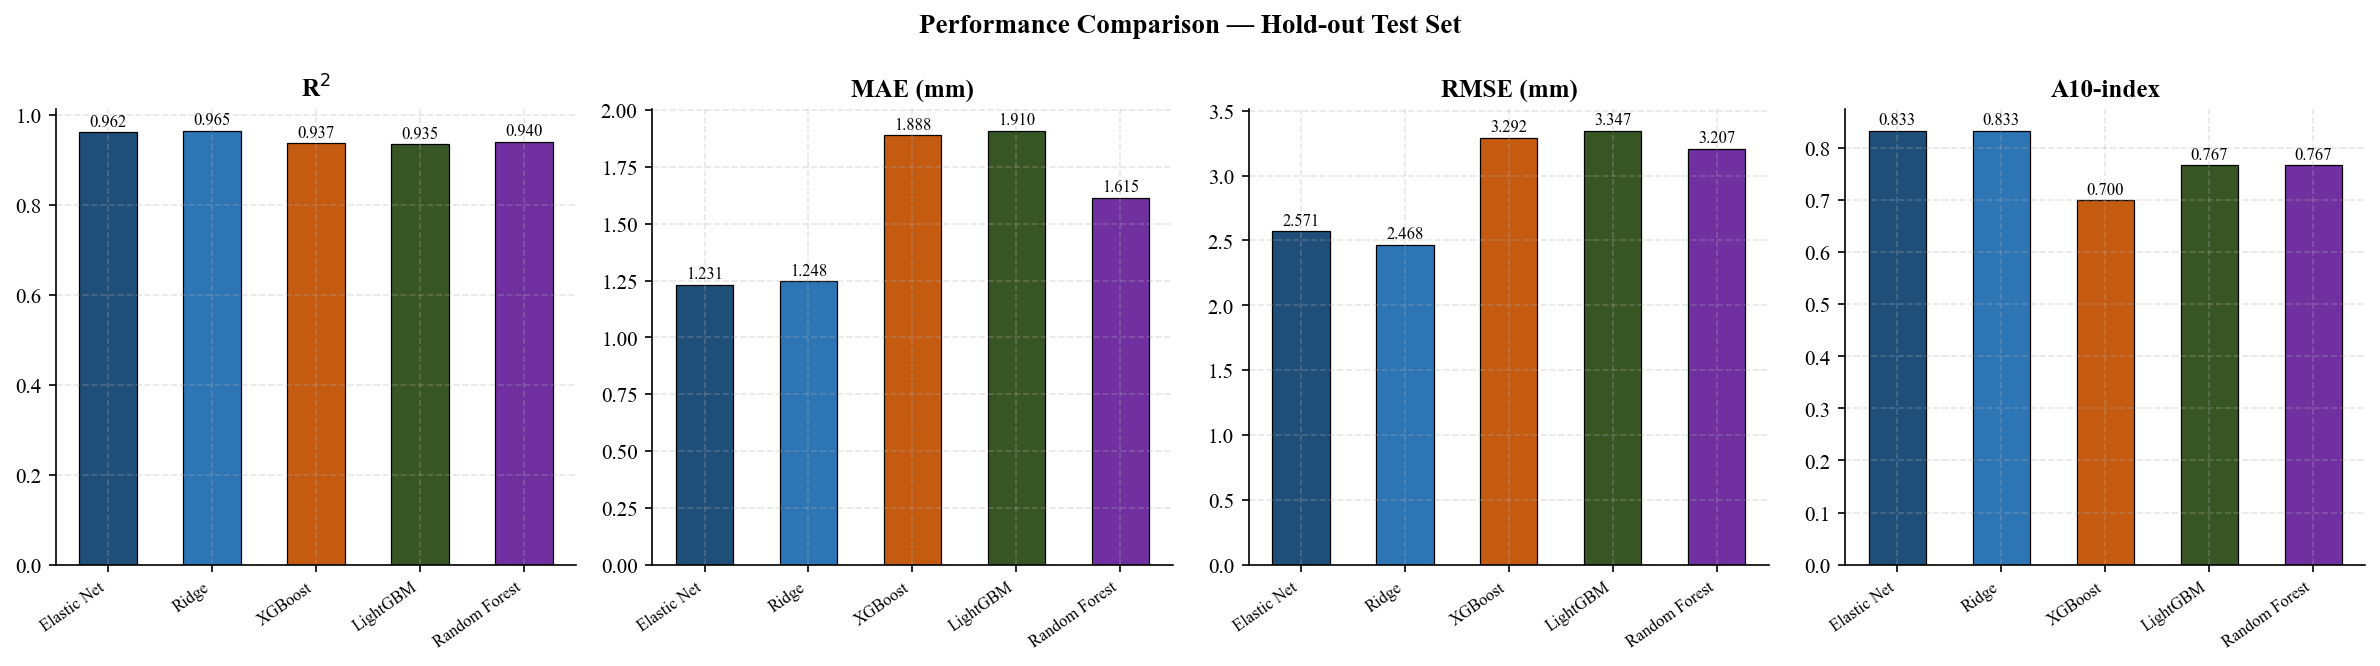

In [10]:

test_df = metrics_df[metrics_df['Set'] == 'Test'].copy()
short_labels = [cfg['label'].replace('Stacking + ','') for cfg in META_CONFIGS.values()]
colors       = [cfg['color'] for cfg in META_CONFIGS.values()]

mets = ['R2', 'MAE (mm)', 'RMSE (mm)', 'A10-index']
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, met in zip(axes, mets):
    vals = test_df[met].values
    bars = ax.bar(short_labels, vals, color=colors, width=0.55,
                  edgecolor='k', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005*max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    display_met = 'R$^2$' if met=='R2' else met
    ax.set_title(display_met, fontweight='bold')
    ax.set_xticklabels(short_labels, rotation=35, ha='right', fontsize=8)

fig.suptitle('Performance Comparison — Hold-out Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bar_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.5 Spider / Radar Performance Plot

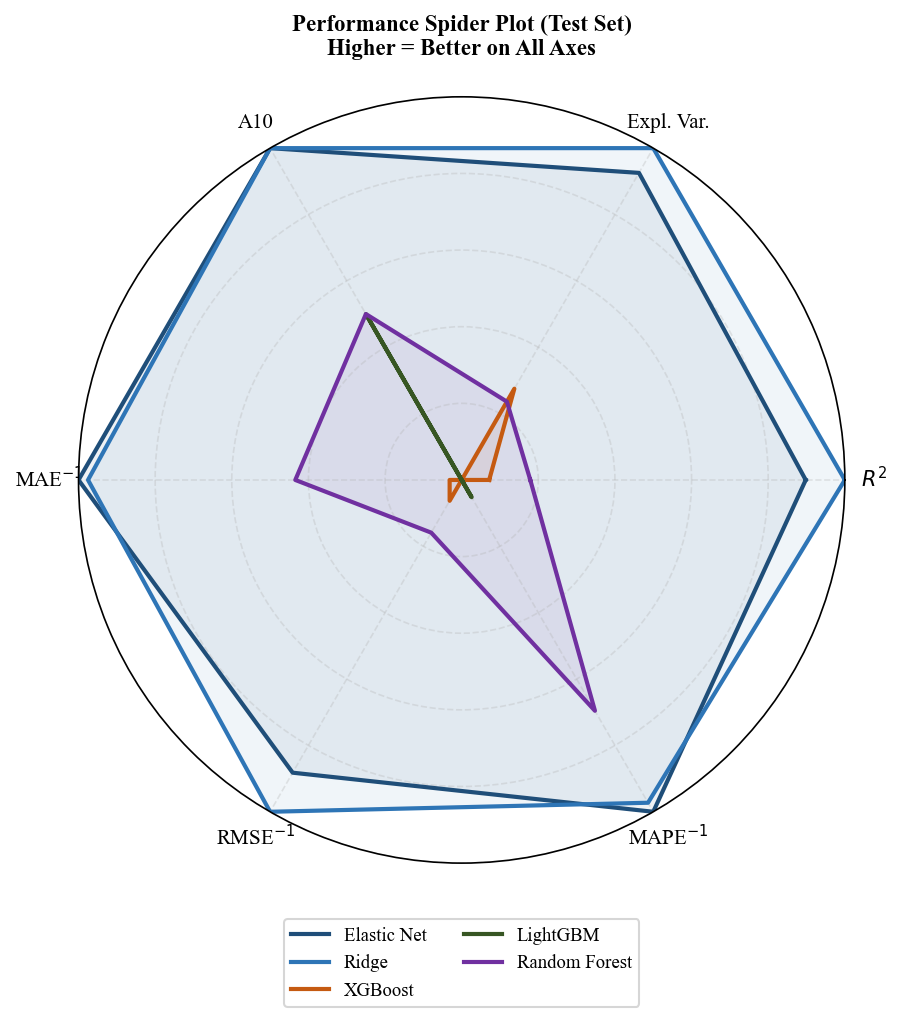

In [11]:

SPIDER_POSITIVE = ['R2', 'Explained Var.', 'A10-index']
SPIDER_NEGATIVE = ['MAE (mm)', 'RMSE (mm)', 'MAPE (%)']
all_spider = SPIDER_POSITIVE + SPIDER_NEGATIVE
n_sp = len(all_spider)

test_sub = metrics_df[metrics_df['Set']=='Test'].copy()

arr = []
for name, cfg in META_CONFIGS.items():
    row = test_sub[test_sub['Model']==cfg['label']].iloc[0]
    arr.append([row[m] for m in all_spider])
arr = np.array(arr)

# normalise each metric
mn, mx = arr.min(0), arr.max(0)
rng = mx - mn + 1e-12
norm = (arr - mn) / rng

# invert negative metrics
for i, m in enumerate(all_spider):
    if m in SPIDER_NEGATIVE:
        norm[:, i] = 1 - norm[:, i]

spider_labels = ['$R^2$', 'Expl. Var.', 'A10', 'MAE$^{-1}$', 'RMSE$^{-1}$', 'MAPE$^{-1}$']
angles = np.linspace(0, 2*np.pi, n_sp, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, (name, cfg) in enumerate(META_CONFIGS.items()):
    vals = norm[i].tolist() + [norm[i][0]]
    ax.plot(angles, vals, lw=2.0, color=cfg['color'],
            label=cfg['label'].replace('Stacking + ',''))
    ax.fill(angles, vals, alpha=0.07, color=cfg['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(spider_labels, fontsize=10)
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.set_title('Performance Spider Plot (Test Set)\nHigher = Better on All Axes',
             fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.20), ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('fig_spider.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.6 Regression Error Characteristic (REC) Curve

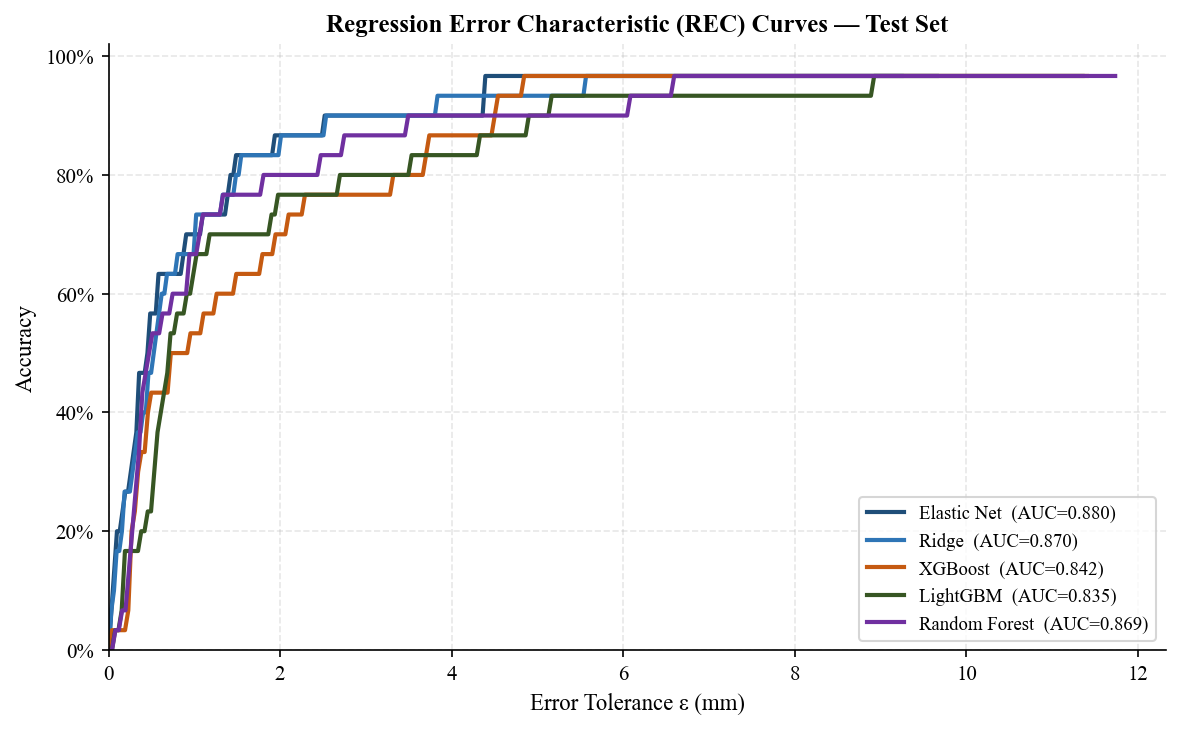

In [13]:

def rec_curve(y_true, y_pred, n_points=300):
    ae      = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    eps_max = np.percentile(ae, 99)
    eps_arr = np.linspace(0, eps_max, n_points)
    acc     = np.array([np.mean(ae <= e) for e in eps_arr])
    return eps_arr, acc

fig, ax = plt.subplots(figsize=(8, 5))
for name, cfg in META_CONFIGS.items():
    eps, acc = rec_curve(y_test, predictions[name]['test'])
    auc_rec  = float(np.trapz(acc, eps) / (eps[-1] + 1e-10))
    label    = cfg['label'].replace('Stacking + ','')
    ax.plot(eps, acc, lw=2, color=cfg['color'],
            label=f"{label}  (AUC={auc_rec:.3f})")

ax.set_xlabel('Error Tolerance ε (mm)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title('Regression Error Characteristic (REC) Curves — Test Set',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('fig_rec_curve.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.7 Optuna Optimisation History

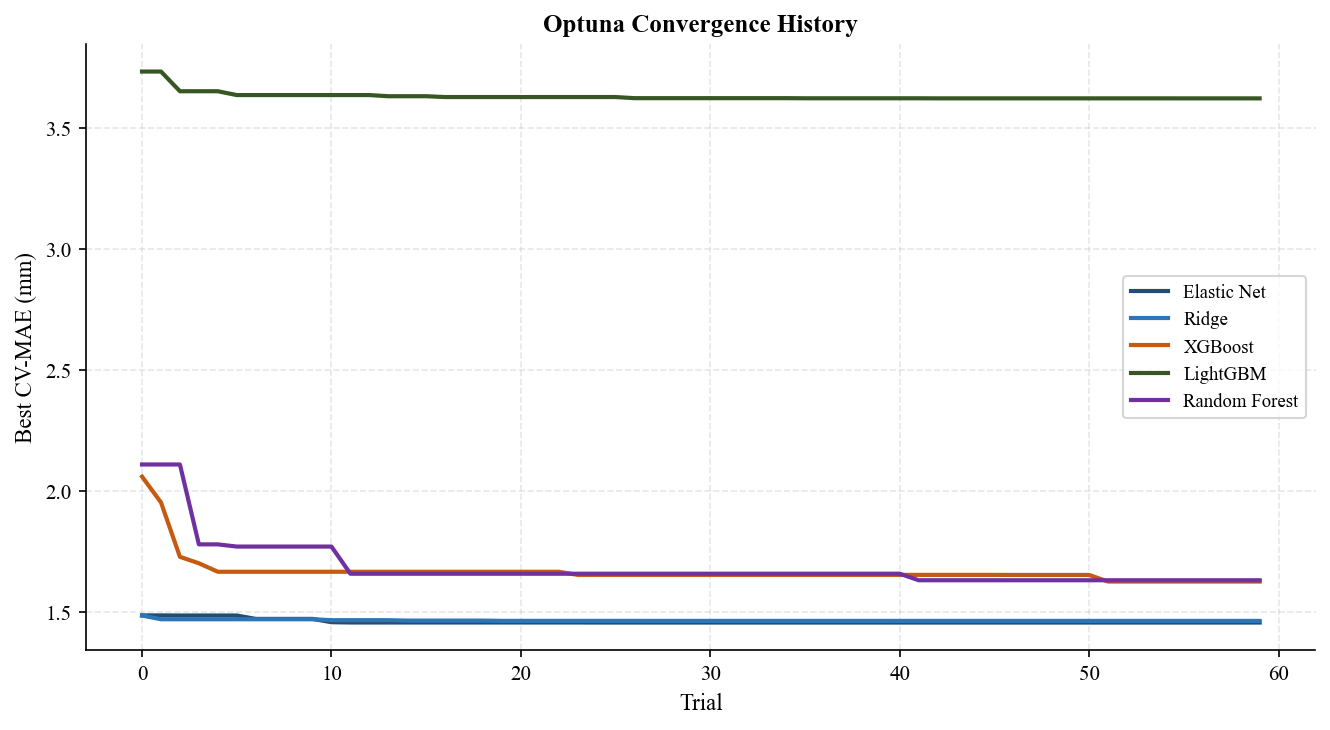

In [14]:

fig, ax = plt.subplots(figsize=(9, 5))
for name, cfg in META_CONFIGS.items():
    vals = np.array(study_values[name])
    ax.plot(np.minimum.accumulate(vals), lw=2, color=cfg['color'],
            label=cfg['label'].replace('Stacking + ',''))

ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('Best CV-MAE (mm)', fontsize=11)
ax.set_title('Optuna Convergence History', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_optuna_history.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.8 Taylor Diagram

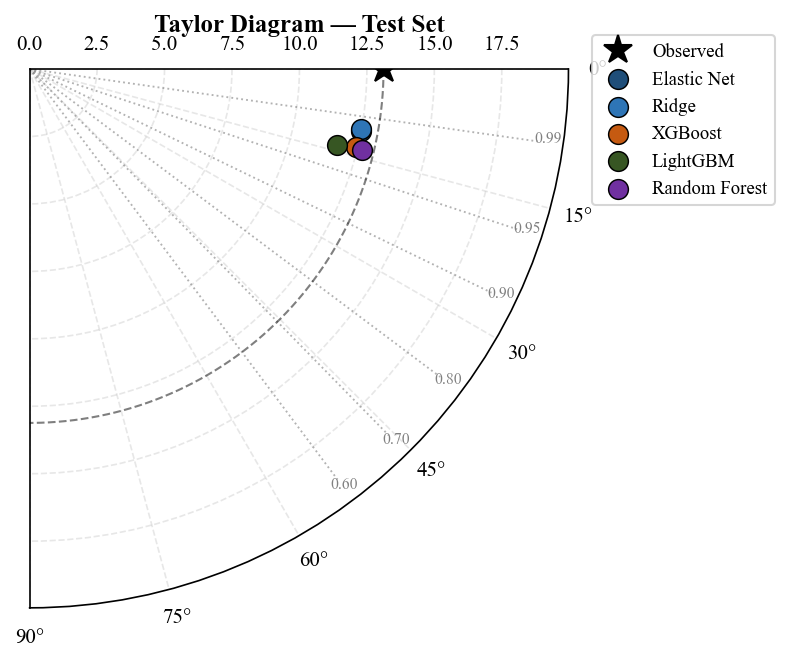

In [15]:

fig = plt.figure(figsize=(7.5, 6))
ax  = fig.add_subplot(111, polar=True)

ref_std = float(np.std(y_test))

# Reference point
ax.plot([0], [ref_std], 'k*', ms=14, zorder=10, label='Observed')

# Correlation arcs
for corr in [0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    t = np.arccos(corr)
    ax.plot([t, t], [0, ref_std*1.45], ':', color='grey', lw=0.9, alpha=0.6)
    ax.text(t, ref_std*1.48, f'{corr:.2f}', fontsize=7.5,
            ha='center', color='grey')

# STD arc of reference
arc = np.linspace(0, np.pi/2, 200)
ax.plot(arc, np.full_like(arc, ref_std), 'k--', lw=1.0, alpha=0.5)

# Models
for name, cfg in META_CONFIGS.items():
    yp     = predictions[name]['test']
    corr   = float(np.corrcoef(y_test, yp)[0, 1])
    std_p  = float(np.std(yp))
    theta  = np.arccos(np.clip(corr, -1, 1))
    ax.scatter([theta], [std_p], s=90, color=cfg['color'],
               edgecolors='k', linewidths=0.7, zorder=8,
               label=cfg['label'].replace('Stacking + ',''))

ax.set_thetamax(90)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_rlabel_position(135)
ax.set_title('Taylor Diagram — Test Set', fontsize=12,
             fontweight='bold', pad=18)
ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.08), fontsize=9)
plt.tight_layout()
plt.savefig('fig_taylor.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.9 10-Fold CV Score Distribution

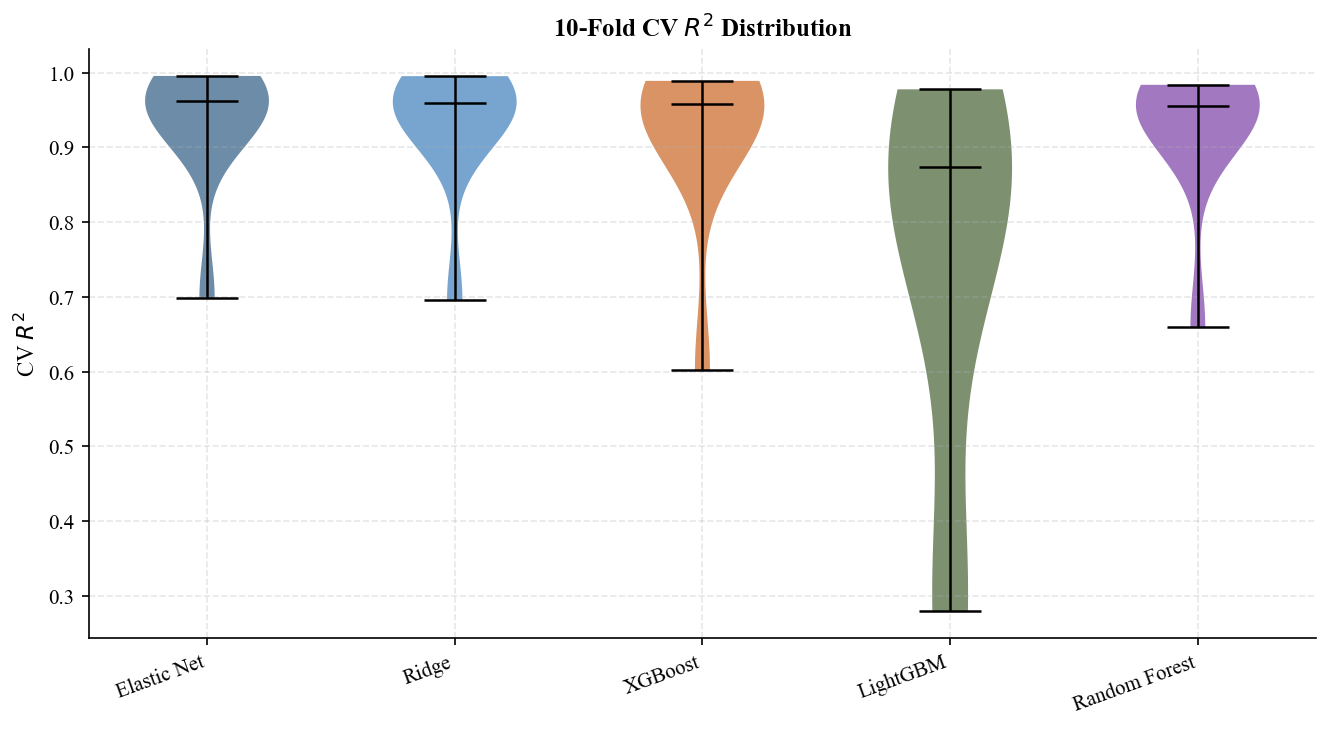

In [16]:

kf10   = KFold(10, shuffle=True, random_state=RANDOM_STATE)
cv_all = {}

for name, cfg in META_CONFIGS.items():
    meta   = build_meta(name, best_params[name])
    stk    = StackingRegressor(estimators=get_base_estimators(),
                               final_estimator=meta,
                               cv=5, passthrough=False, n_jobs=-1)
    scores = cross_val_score(stk, X_train_s, y_train,
                             cv=kf10, scoring='r2', n_jobs=-1)
    cv_all[cfg['label'].replace('Stacking + ','')] = scores

cv_df = pd.DataFrame(cv_all)
colors_list = [cfg['color'] for cfg in META_CONFIGS.values()]

fig, ax = plt.subplots(figsize=(9, 5))
parts   = ax.violinplot(cv_df.values, showmedians=True, showextrema=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_list[i]); pc.set_alpha(0.65)
for key in ('cmedians','cbars','cmins','cmaxes'):
    parts[key].set_color('k'); parts[key].set_linewidth(1.2)

ax.set_xticks(range(1, len(cv_df.columns)+1))
ax.set_xticklabels(cv_df.columns, rotation=20, ha='right')
ax.set_ylabel('CV $R^2$')
ax.set_title('10-Fold CV $R^2$ Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cv_violin.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.10 Training Time Comparison

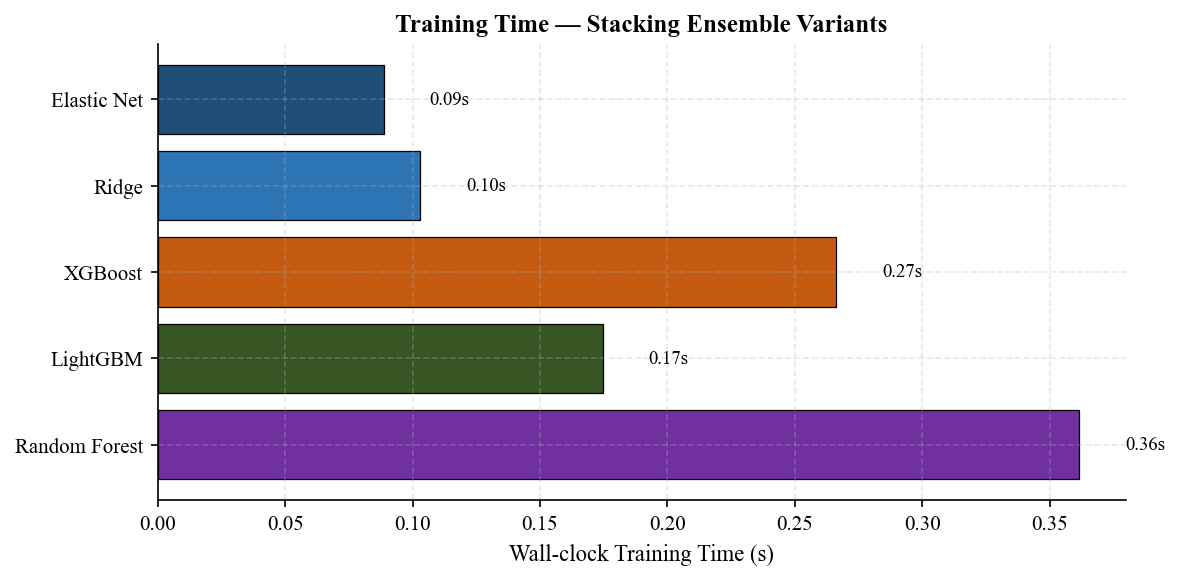

In [17]:

short_names = [cfg['label'].replace('Stacking + ','') for cfg in META_CONFIGS.values()]
times_list  = [train_times[n] for n in META_CONFIGS]
cols        = [cfg['color'] for cfg in META_CONFIGS.values()]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(short_names, times_list, color=cols, edgecolor='k', linewidth=0.6)
for bar, t in zip(bars, times_list):
    ax.text(t + 0.05*max(times_list), bar.get_y() + bar.get_height()/2,
            f'{t:.2f}s', va='center', fontsize=9)
ax.set_xlabel('Wall-clock Training Time (s)')
ax.set_title('Training Time — Stacking Ensemble Variants',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_train_time.png', dpi=300, bbox_inches='tight')
plt.show()


### 7.11 Performance Heatmap

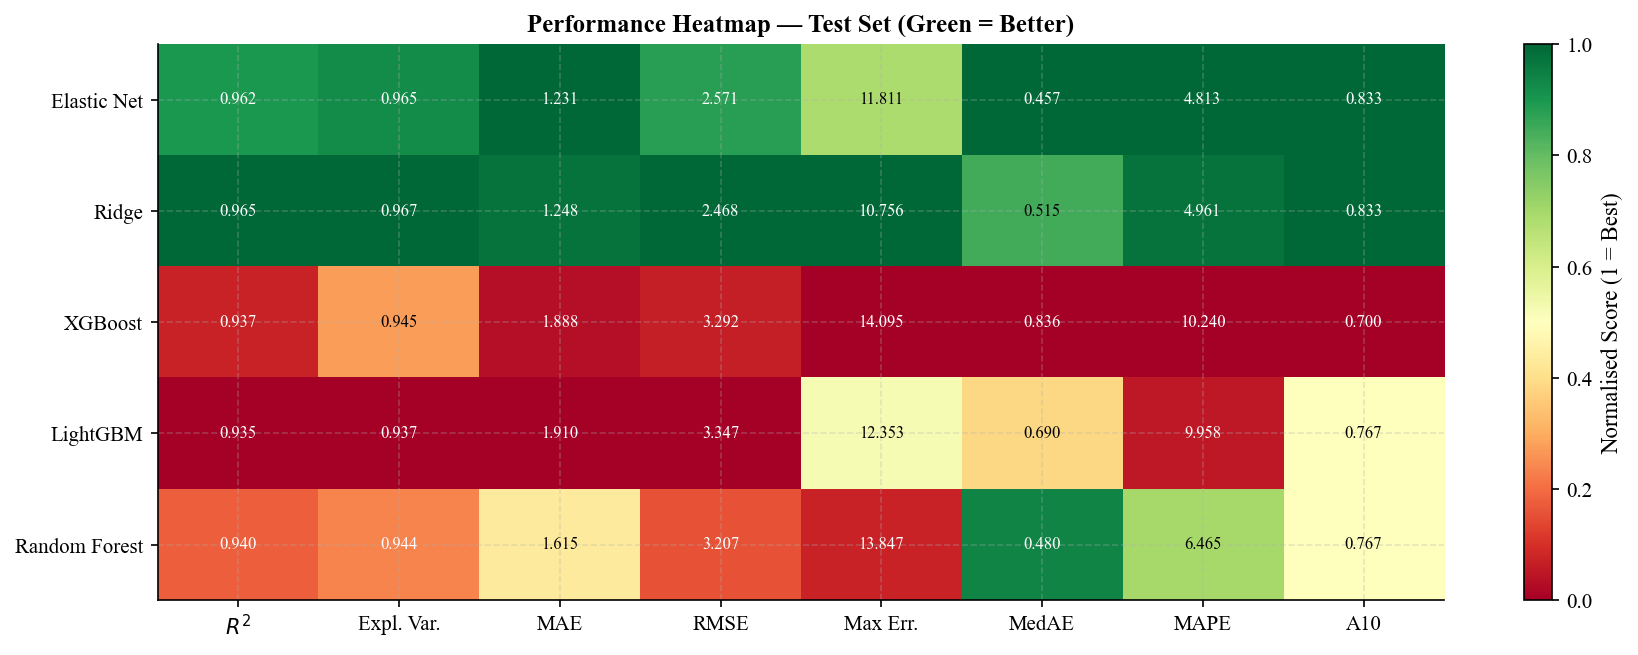

In [18]:

heat_cols = ['R2','Explained Var.','MAE (mm)','RMSE (mm)',
             'Max Error (mm)','MedAE (mm)','MAPE (%)','A10-index']

test_heat = (metrics_df[metrics_df['Set']=='Test']
             .set_index('Model')[heat_cols].astype(float))
test_heat.index = [cfg['label'].replace('Stacking + ','')
                   for cfg in META_CONFIGS.values()]

norm_h = test_heat.copy()
for col in heat_cols:
    rng = norm_h[col].max() - norm_h[col].min()
    norm_h[col] = (norm_h[col] - norm_h[col].min()) / (rng + 1e-12)
for col in ['MAE (mm)','RMSE (mm)','Max Error (mm)','MedAE (mm)','MAPE (%)']:
    norm_h[col] = 1 - norm_h[col]

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(norm_h.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

xlabels = ['$R^2$','Expl. Var.','MAE','RMSE','Max Err.','MedAE','MAPE','A10']
ax.set_xticks(range(len(heat_cols))); ax.set_xticklabels(xlabels, fontsize=10)
ax.set_yticks(range(len(norm_h)));    ax.set_yticklabels(norm_h.index, fontsize=10)

for i in range(len(norm_h)):
    for j, col in enumerate(heat_cols):
        raw = test_heat.iloc[i, j]
        ax.text(j, i, f'{raw:.3f}', ha='center', va='center', fontsize=8,
                color='white' if norm_h.iloc[i,j] < 0.25 or norm_h.iloc[i,j] > 0.85 else 'black')

plt.colorbar(im, ax=ax, label='Normalised Score (1 = Best)')
ax.set_title('Performance Heatmap — Test Set (Green = Better)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



## 8. SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) values are computed for the **best-performing**
stacking model using `KernelExplainer`, which is fully model-agnostic and operates
on the original feature space.

All plots use the **formal feature labels** defined in Section 2.


In [19]:

# Identify best model by test R2
test_r2   = {n: r2_score(y_test, predictions[n]['test']) for n in META_CONFIGS}
best_name = max(test_r2, key=test_r2.get)
best_cfg  = META_CONFIGS[best_name]
best_stk  = fitted_models[best_name]

print(f"Best model for SHAP: {best_cfg['label']}  (Test R2 = {test_r2[best_name]:.4f})")
print("\nComputing SHAP KernelExplainer (may take 1-3 min) ...")

X_bg      = shap.kmeans(X_train_s, 20)
explainer = shap.KernelExplainer(best_stk.predict, X_bg)
shap_vals = explainer.shap_values(X_test_s, nsamples=100, silent=True)

print(f"SHAP values shape: {np.array(shap_vals).shape}")


Best model for SHAP: Stacking + Ridge  (Test R2 = 0.9646)

Computing SHAP KernelExplainer (may take 1-3 min) ...
SHAP values shape: (30, 8)


### 8.1 SHAP Beeswarm Summary Plot

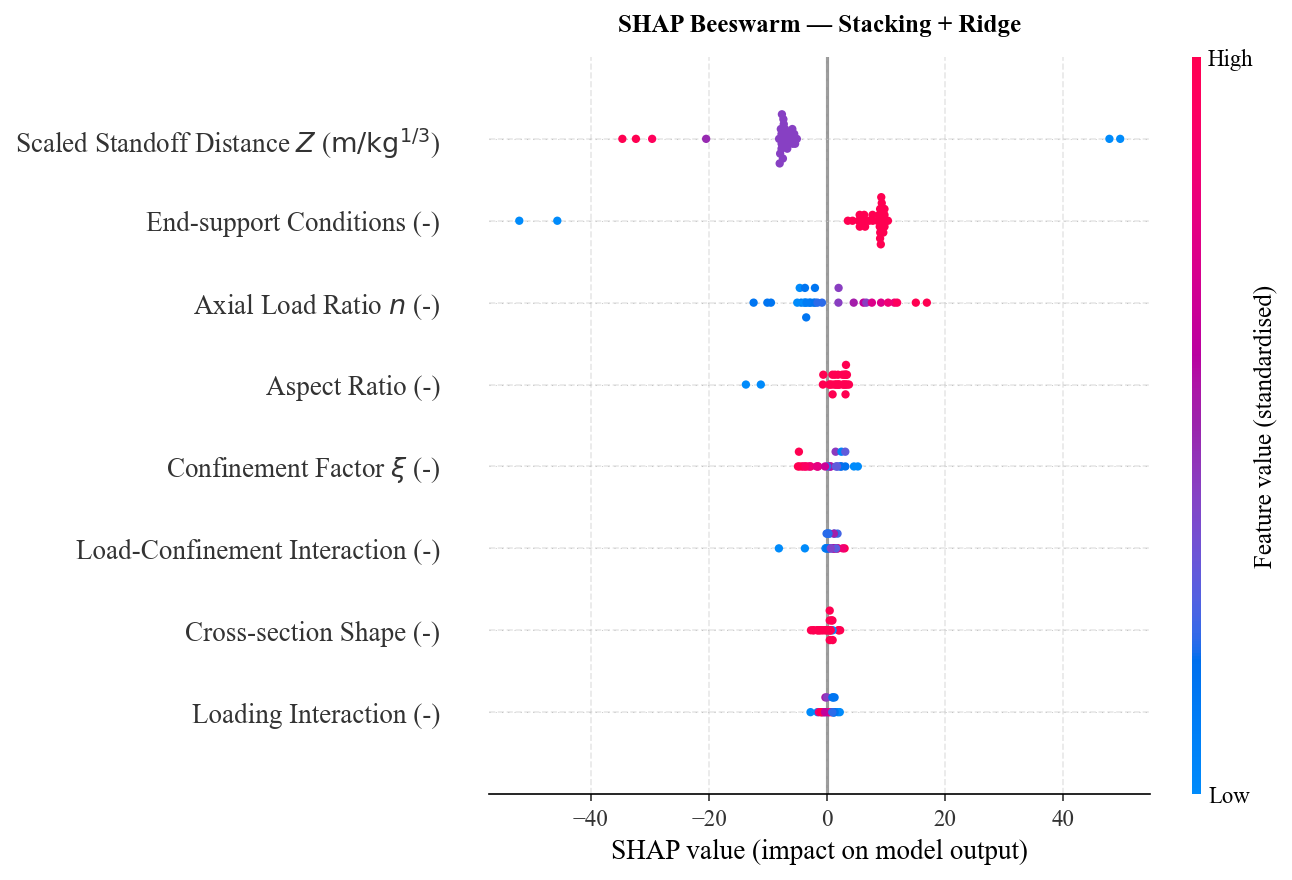

In [20]:

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_vals, X_test_s, feature_names=feat_labels_list,
                  show=False, plot_size=None,
                  color_bar_label='Feature value (standardised)')
plt.title(f'SHAP Beeswarm — {best_cfg["label"]}',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()


### 8.2 SHAP Feature Importance (Mean |SHAP|)

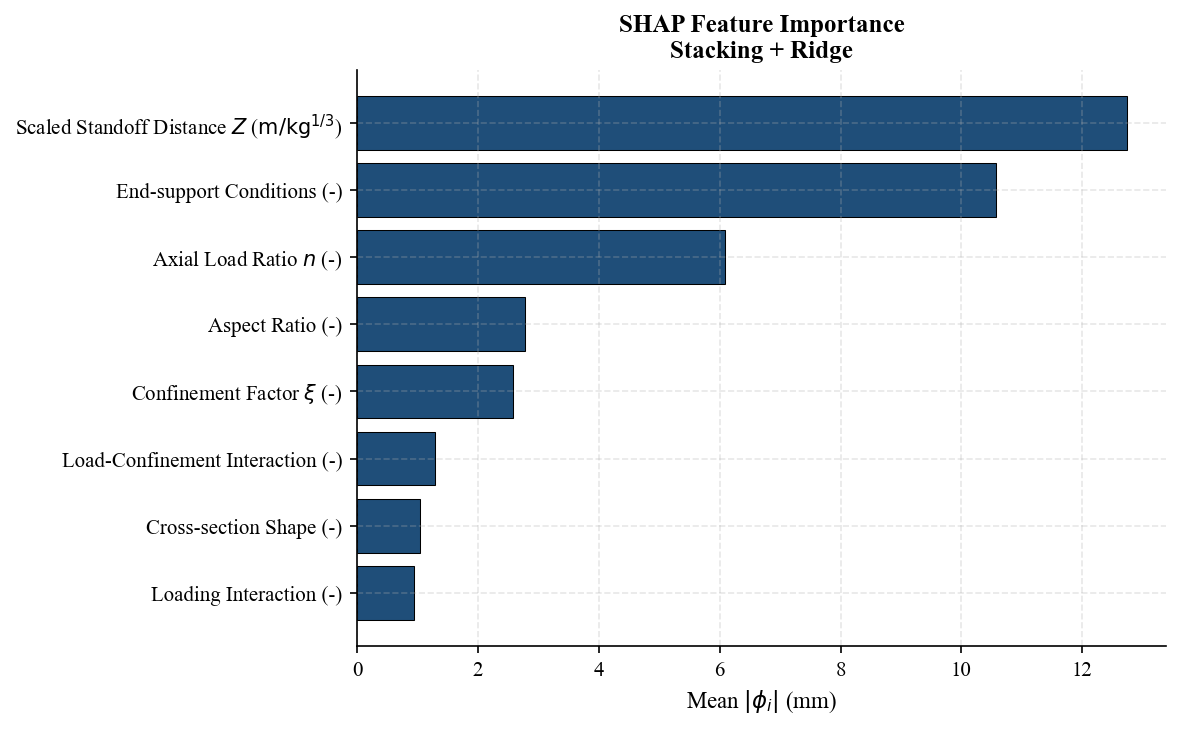

In [21]:

mean_abs = np.abs(shap_vals).mean(0)
order    = np.argsort(mean_abs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([feat_labels_list[i] for i in order],
         mean_abs[order],
         color='#1f4e79', edgecolor='k', linewidth=0.5)
ax.set_xlabel(r'Mean $|\phi_i|$ (mm)', fontsize=11)
ax.set_title(f'SHAP Feature Importance\n{best_cfg["label"]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()


### 8.3 SHAP Force Plot (Single Sample)

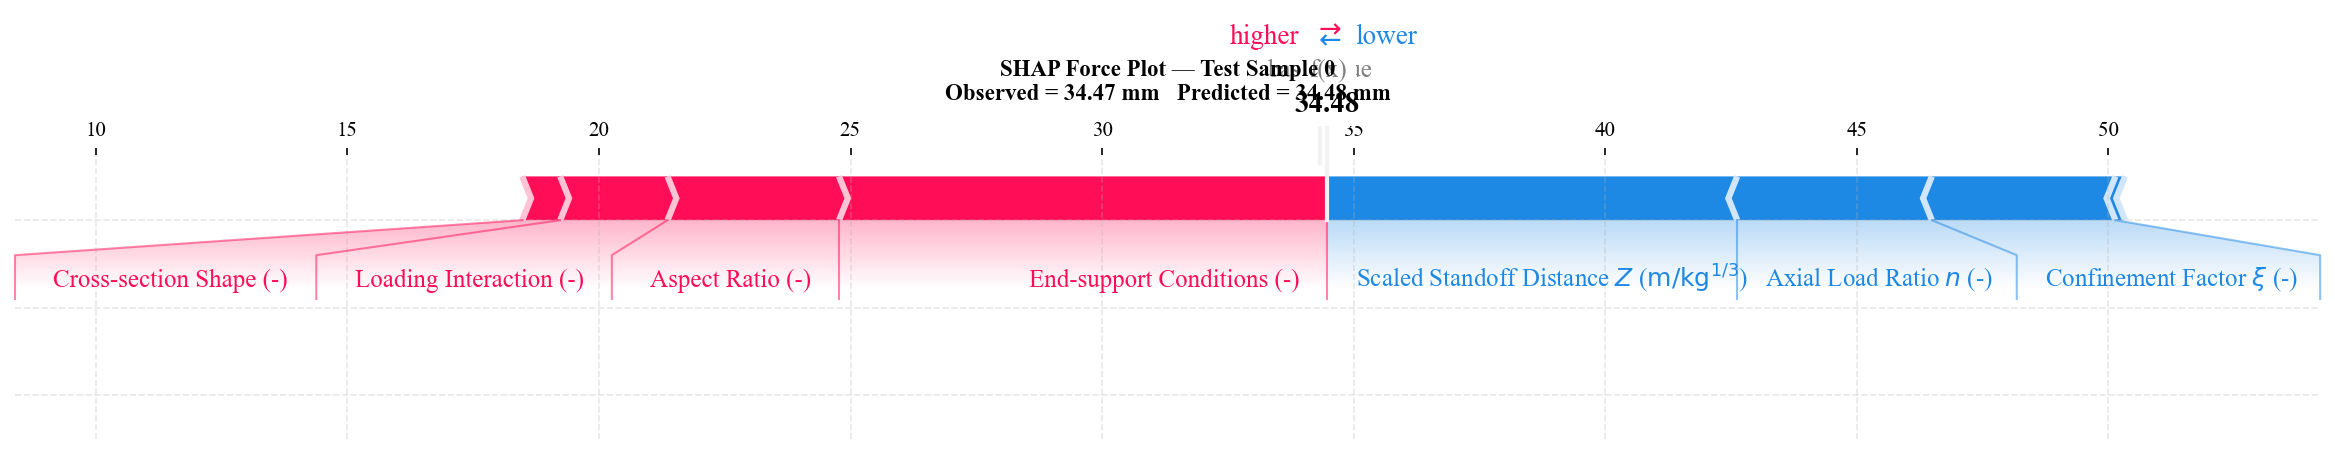

In [22]:

sample_idx = 0
obs_val  = float(y_test.iloc[sample_idx])
pred_val = float(best_stk.predict(X_test_s[sample_idx:sample_idx+1])[0])

shap.force_plot(
    explainer.expected_value,
    shap_vals[sample_idx],
    feature_names=feat_labels_list,
    matplotlib=True,
    show=False,
    figsize=(16, 3.5)
)
plt.title(
    f'SHAP Force Plot — Test Sample {sample_idx}\n'
    f'Observed = {obs_val:.2f} mm   Predicted = {pred_val:.2f} mm',
    fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig_shap_force.png', dpi=300, bbox_inches='tight')
plt.show()


### 8.4 SHAP Dependence Plots — Top-3 Features

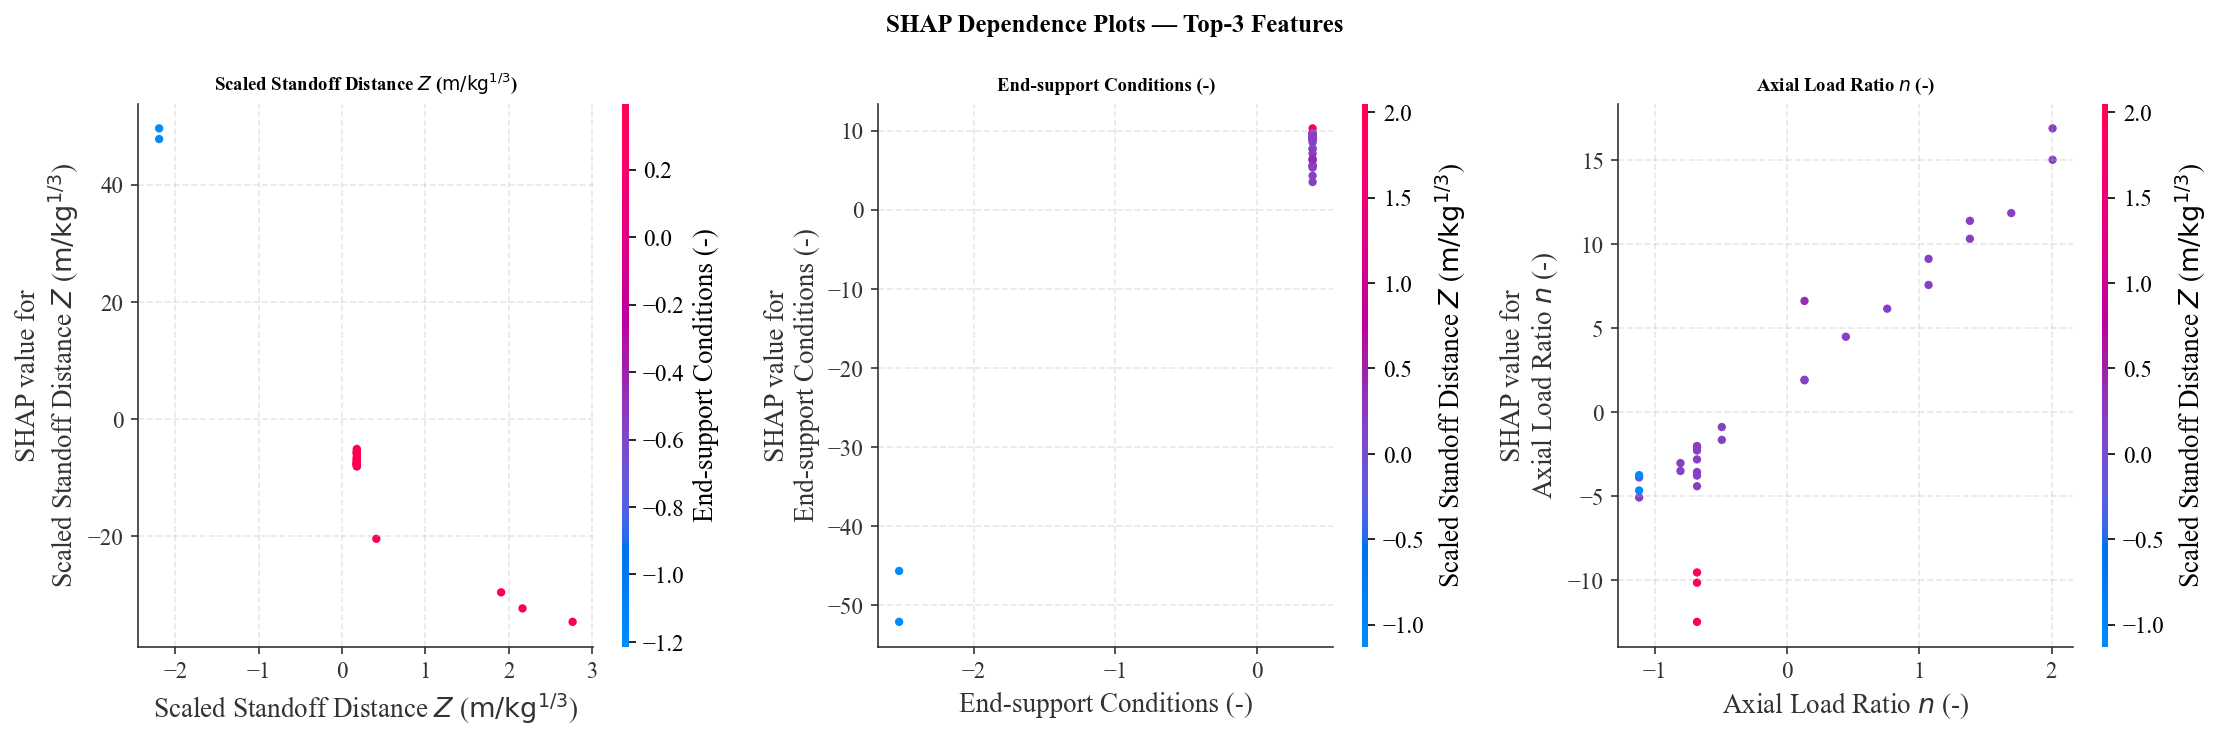

In [23]:

top3 = np.argsort(mean_abs)[::-1][:3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, top3):
    inter = next(i for i in np.argsort(mean_abs)[::-1] if i != idx)
    shap.dependence_plot(
        idx, shap_vals, X_test_s,
        feature_names=feat_labels_list,
        interaction_index=inter,
        ax=ax, show=False)
    ax.set_title(feat_labels_list[idx], fontsize=9, fontweight='bold')

fig.suptitle('SHAP Dependence Plots — Top-3 Features',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Optimal Hyperparameter Summary Table

In [24]:

param_rows = []
for name, cfg in META_CONFIGS.items():
    row = {'Model': cfg['label'], 'Train Time (s)': round(train_times[name], 3)}
    for k, v in best_params[name].items():
        row[k] = round(v, 6) if isinstance(v, float) else v
    param_rows.append(row)

param_df = pd.DataFrame(param_rows).fillna('--')
param_df.index = range(1, len(param_df)+1)
print(param_df.to_string())


                      Model  Train Time (s)    alpha l1_ratio n_estimators max_depth learning_rate subsample colsample_bytree reg_alpha reg_lambda num_leaves min_samples_split min_samples_leaf
1    Stacking + Elastic Net          0.0890   4.1221   0.0129           --        --            --        --               --        --         --         --                --               --
2          Stacking + Ridge          0.1030 198.5563       --           --        --            --        --               --        --         --         --                --               --
3        Stacking + XGBoost          0.2660       --       --     223.0000    3.0000        0.0418    0.6430           0.9559    0.0003     6.0050         --                --               --
4       Stacking + LightGBM          0.1750       --       --     366.0000        --        0.0232    0.6977           0.8340    0.0011     0.0648   109.0000                --               --
5  Stacking + Random Forest        